In [16]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [3]:
transform= transforms.ToTensor()
training_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data= datasets.MNIST(root='data', train =False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 347kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.36MB/s]


In [4]:
train_loader= DataLoader(training_data, batch_size=64, shuffle=True)
test_loader=DataLoader(test_data, batch_size=64, shuffle=False)

In [5]:
class MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.CNN1=nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.relu=nn.ReLU()
        self.mxp= nn.MaxPool2d(kernel_size=2, stride=2)
        self.CNN2=nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.flatten=nn.Flatten()
        self.lin1=nn.Linear(1600, 800)
        self.lin2=nn.Linear(800, 10)
    
        
    def forward(self, x):
        x= self.CNN1(x)
        x=self.relu(x)
        x=self.mxp(x)
        x=self.CNN2(x)
        x=self.relu(x)
        x=self.mxp(x)
        x=self.flatten(x)
        x=self.lin1(x)
        x=self.relu(x)
        x=self.lin2(x)
        return x
        

In [6]:
model = MNIST().to(device)
loss_fn = nn.CrossEntropyLoss()
optim = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10
totaloss = 0

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optim.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        totaloss += loss
        loss.backward()
        optim.step()
    print(totaloss.item())
    totaloss = 0

138.7997283935547
40.802886962890625
27.714218139648438
18.61631965637207
14.329859733581543
11.693984031677246
9.234978675842285
8.177574157714844
6.450051307678223
5.9822916984558105


In [7]:
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    print(f'Accuracy: {correct/total*100:.2f}%')

Accuracy: 99.11%


In [8]:
torch.save(model.state_dict(), 'mnist_model.pth')


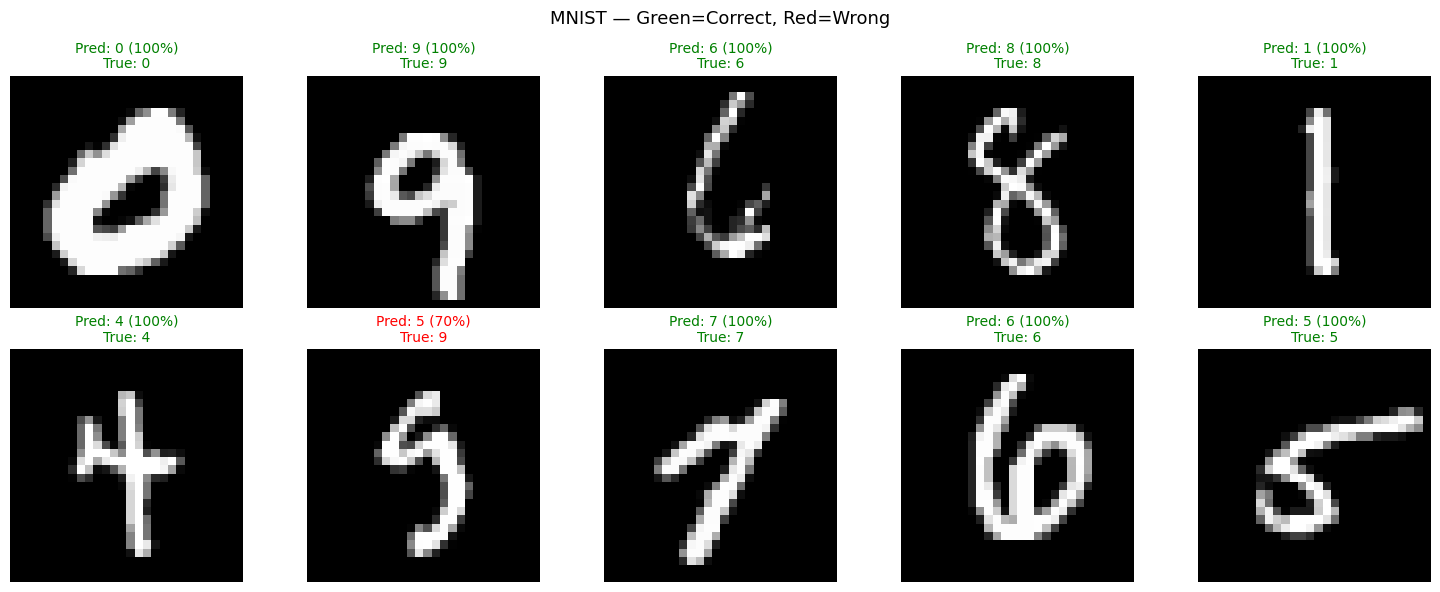

Saved as mnist_inference.png


In [17]:
model.eval()
indices = np.random.choice(len(test_data), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

with torch.no_grad():
    for i, idx in enumerate(indices):
        image, label = test_data[idx]
        output = model(image.unsqueeze(0).to(device))
        predicted  = output.argmax(dim=1).item()
        confidence = torch.softmax(output, dim=1).max().item()

        axes[i].imshow(image.squeeze(), cmap='gray')
        axes[i].axis('off')
        color = 'green' if predicted == label else 'red'
        axes[i].set_title(
            f"Pred: {predicted} ({confidence:.0%})\nTrue: {label}",
            color=color, fontsize=10
        )

plt.suptitle('MNIST — Green=Correct, Red=Wrong', fontsize=13)
plt.tight_layout()
plt.savefig('mnist_inference.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as mnist_inference.png")